In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
# Download Customer Churn dataset

!wget -O churn.csv "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

print("Dataset downloaded successfully!")

--2026-08-21 09:56:46--  https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: ‘churn.csv’

churn.csv           100%[===================>] 947.71K  --.-KB/s    in 0.03s   

2026-08-21 09:56:46 (27.0 MB/s) - ‘churn.csv’ saved [970457/970457]

Dataset downloaded successfully!


In [6]:
# Load the customer churn dataset

df = pd.read_csv("churn.csv")

print("Dataset loaded successfully!")

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display first 10 rows
df.head(10)

Dataset loaded successfully!
Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [7]:
# Display basic information about the dataset

print("Column Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   I

In [ ]:
# Check missing values in each column

print("Missing Values:")
print(df.isnull().sum())

In [8]:
# Check number of customers who stayed and churned

print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
# Convert TotalCharges into numeric format

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges values with the median

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Check missing values again

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Remove customer ID because it is not useful for prediction

df = df.drop("customerID", axis=1)

# Display dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Convert Churn values into numerical values

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Check the result

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
# Convert categorical columns into numerical columns

df = pd.get_dummies(df, drop_first=True)

# Display the converted dataset

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [13]:
# X contains input features
# y contains the target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 30)
Target Shape: (7043,)


In [14]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 30)
Testing Data: (1409, 30)


In [15]:
# Standardize the numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Train Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions

lr_pred = lr_model.predict(
    X_test_scaled
)

# Calculate accuracy

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 80.7 %


In [36]:
# Train Decision Tree model

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

# Make predictions

dt_pred = dt_model.predict(X_test)

# Calculate accuracy

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 79.42 %


In [37]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

# Make predictions

rf_pred = rf_model.predict(X_test)

# Calculate accuracy

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 80.34 %


In [38]:
# Train Gradient Boosting model

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

# Make predictions

gb_pred = gb_model.predict(X_test)

# Calculate accuracy

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

print(
    "Gradient Boosting Accuracy:",
    round(gb_accuracy * 100, 2),
    "%"
)

Gradient Boosting Accuracy: 79.84 %


In [39]:
# Compare all machine learning models

model_accuracy = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "Gradient Boosting": gb_accuracy
}

print("MODEL ACCURACY COMPARISON")
print("=" * 40)

for model, accuracy in model_accuracy.items():
    print(
        model,
        ":",
        round(accuracy * 100, 2),
        "%"
    )

MODEL ACCURACY COMPARISON
Logistic Regression : 80.7 %
Decision Tree : 79.42 %
Random Forest : 80.34 %
Gradient Boosting : 79.84 %


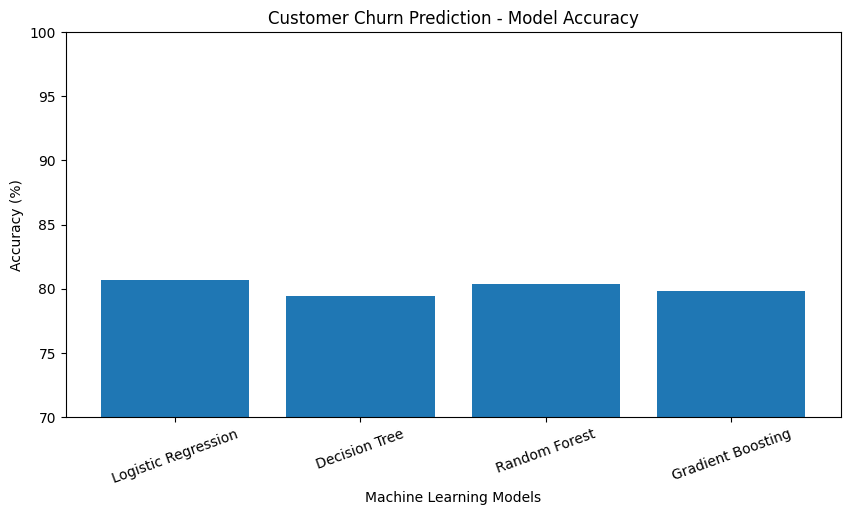

In [40]:
# Create accuracy comparison graph

models = list(model_accuracy.keys())

accuracies = [
    accuracy * 100
    for accuracy in model_accuracy.values()
]

plt.figure(figsize=(10, 5))

plt.bar(
    models,
    accuracies
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.title(
    "Customer Churn Prediction - Model Accuracy"
)

plt.ylim(70, 100)

plt.xticks(rotation=20)

plt.show()

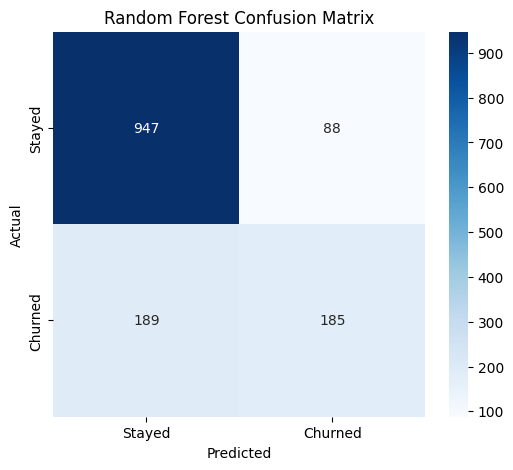

In [22]:
# Generate confusion matrix for Random Forest

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [23]:
# Display classification report for Random Forest

print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Stayed", "Churned"]
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

      Stayed       0.83      0.91      0.87      1035
     Churned       0.68      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [24]:
# Find important features using Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 important features

print(feature_importance.head(10))

                                 Feature  Importance
1                                 tenure    0.195058
3                           TotalCharges    0.147585
2                         MonthlyCharges    0.092126
10           InternetService_Fiber optic    0.085504
25                     Contract_Two year    0.081776
28        PaymentMethod_Electronic check    0.072575
24                     Contract_One year    0.039956
13                    OnlineSecurity_Yes    0.039015
19                       TechSupport_Yes    0.025092
16  DeviceProtection_No internet service    0.019379


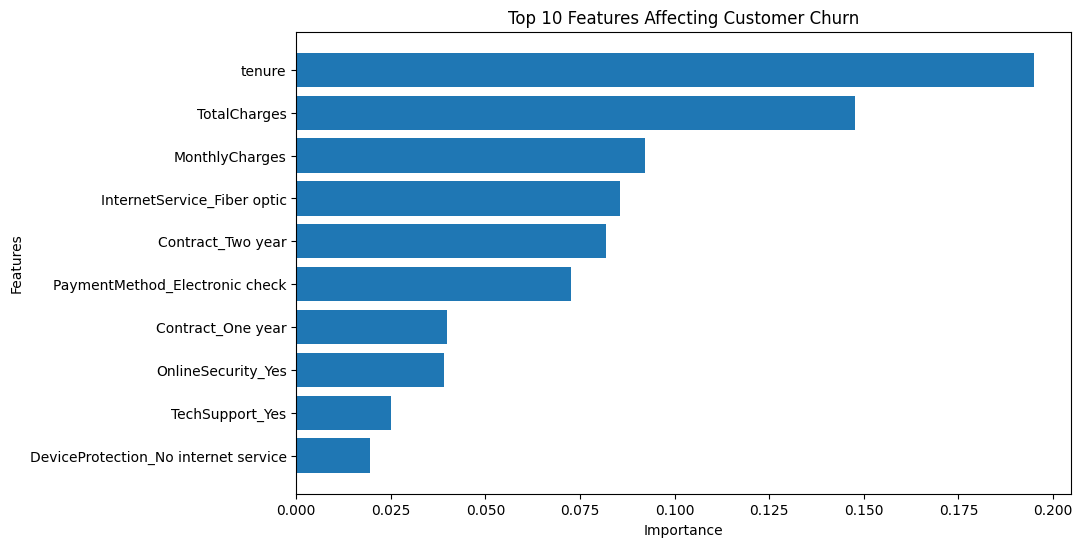

In [25]:
# Plot top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Features Affecting Customer Churn")

plt.gca().invert_yaxis()

plt.show()

In [26]:
# Display final model comparison

print("=" * 50)
print("CUSTOMER CHURN PREDICTION - FINAL RESULTS")
print("=" * 50)

print(
    "Logistic Regression :",
    round(lr_accuracy * 100, 2), "%"
)

print(
    "Decision Tree       :",
    round(dt_accuracy * 100, 2), "%"
)

print(
    "Random Forest       :",
    round(rf_accuracy * 100, 2), "%"
)

print(
    "Gradient Boosting   :",
    round(gb_accuracy * 100, 2), "%"
)

print("=" * 50)

best_model = max(model_accuracy, key=model_accuracy.get)

print("Best Model:", best_model)
print(
    "Best Accuracy:",
    round(model_accuracy[best_model] * 100, 2),
    "%"
)

CUSTOMER CHURN PREDICTION - FINAL RESULTS
Logistic Regression : 80.7 %
Decision Tree       : 79.42 %
Random Forest       : 80.34 %
Gradient Boosting   : 79.84 %
Best Model: Logistic Regression
Best Accuracy: 80.7 %
